In [46]:
import matplotlib.pyplot as plt
import numpy as np

In [47]:
plt.style.use("../mpl_themes/jvc.mplstyle")

In [48]:
def data_loader(fname) -> tuple[np.ndarray, np.ndarray]:
    """Load Energy and Ldos columns total contribution for a given orbital"""
    data = np.loadtxt(fname)
    energy = data[:, 0]
    pdos = data[:, 1]

    return energy, pdos

In [49]:
e_lda, dos_lda = data_loader(r"../DFT_LDA/04_density_of_states/pp_dos/ZnO_LDA_noU.pdos_tot")
e_pbe, dos_pbe = data_loader(r"../DFT_PBE/04_density_of_states/03_pp_dos/ZnO_PBE.pdos_tot")
e_pbeu, dos_pbeu = data_loader(r"../DFT_PBEU/04_DOS/03_ppdos/ZnO_PBEU.pdos_tot")


## Plot em gráfico único

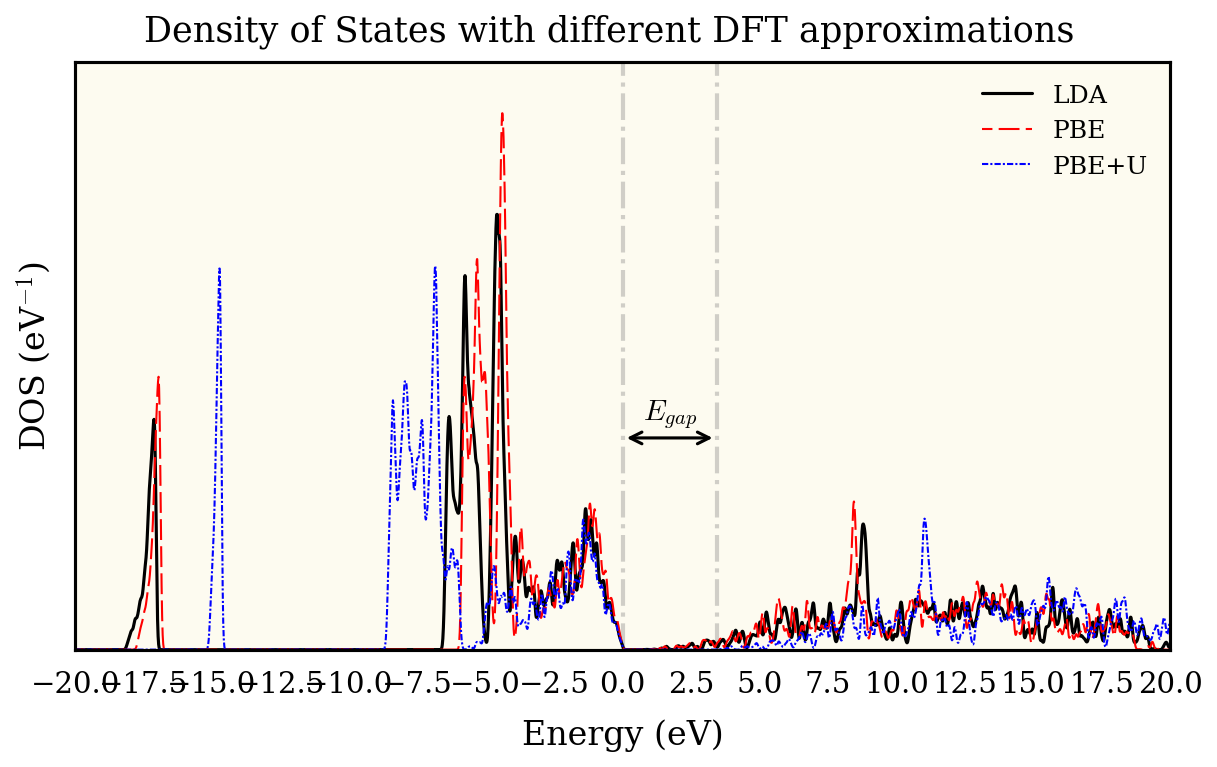

In [50]:
from matplotlib.ticker import MultipleLocator

fermi = {
    "LDA": 10.108,
    "PBE": 9.134,
    "PBE+U": 7.499,
}
colors = {"LDA": "black", "PBE": "red", "PBE+U": "blue"}

fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
fig.suptitle("Density of States with different DFT approximations")

ax.plot(e_lda - fermi["LDA"], dos_lda, lw=1.5, color=colors["LDA"], zorder=2)
ax.plot(e_pbe - fermi["PBE"], dos_pbe, lw=1.0, color=colors["PBE"], ls=(5, (10, 3)))

ls_pbe = (0, (3, 1, 1, 1))
ax.plot(e_pbeu - fermi["PBE+U"], dos_pbeu, color=colors["PBE+U"], lw=1.0, ls=ls_pbe)

ax.set_ylabel(r"DOS (eV$^{-1}$)")
ax.set_xlabel("Energy (eV)")

xmin = 20
ax.set_xlim([-xmin, xmin])
ax.set_ylim([0, 25])

ax.xaxis.set_major_locator(MultipleLocator(2.5))
ax.set_yticks([])
ax.tick_params(axis="x", which="both", length=0)

x_gap_lines = [0, 3.44]
for x in x_gap_lines:
    ax.axvline(x, color="dimgray", ls="-.", alpha=0.3, zorder=0)

ax.annotate(text="$E_{gap}$", xytext=(np.mean(x_gap_lines), 10), xy=(2, 10), ha="center", va="center")

arrow_gap= dict(arrowstyle="<->",lw=1.5,color="black")
ax.annotate("", xy=(3.44, 9),xytext=(0, 9),arrowprops=arrow_gap)

plt.legend(["LDA", "PBE", "PBE+U"])
plt.show()

## Densidade de Estados Vertical

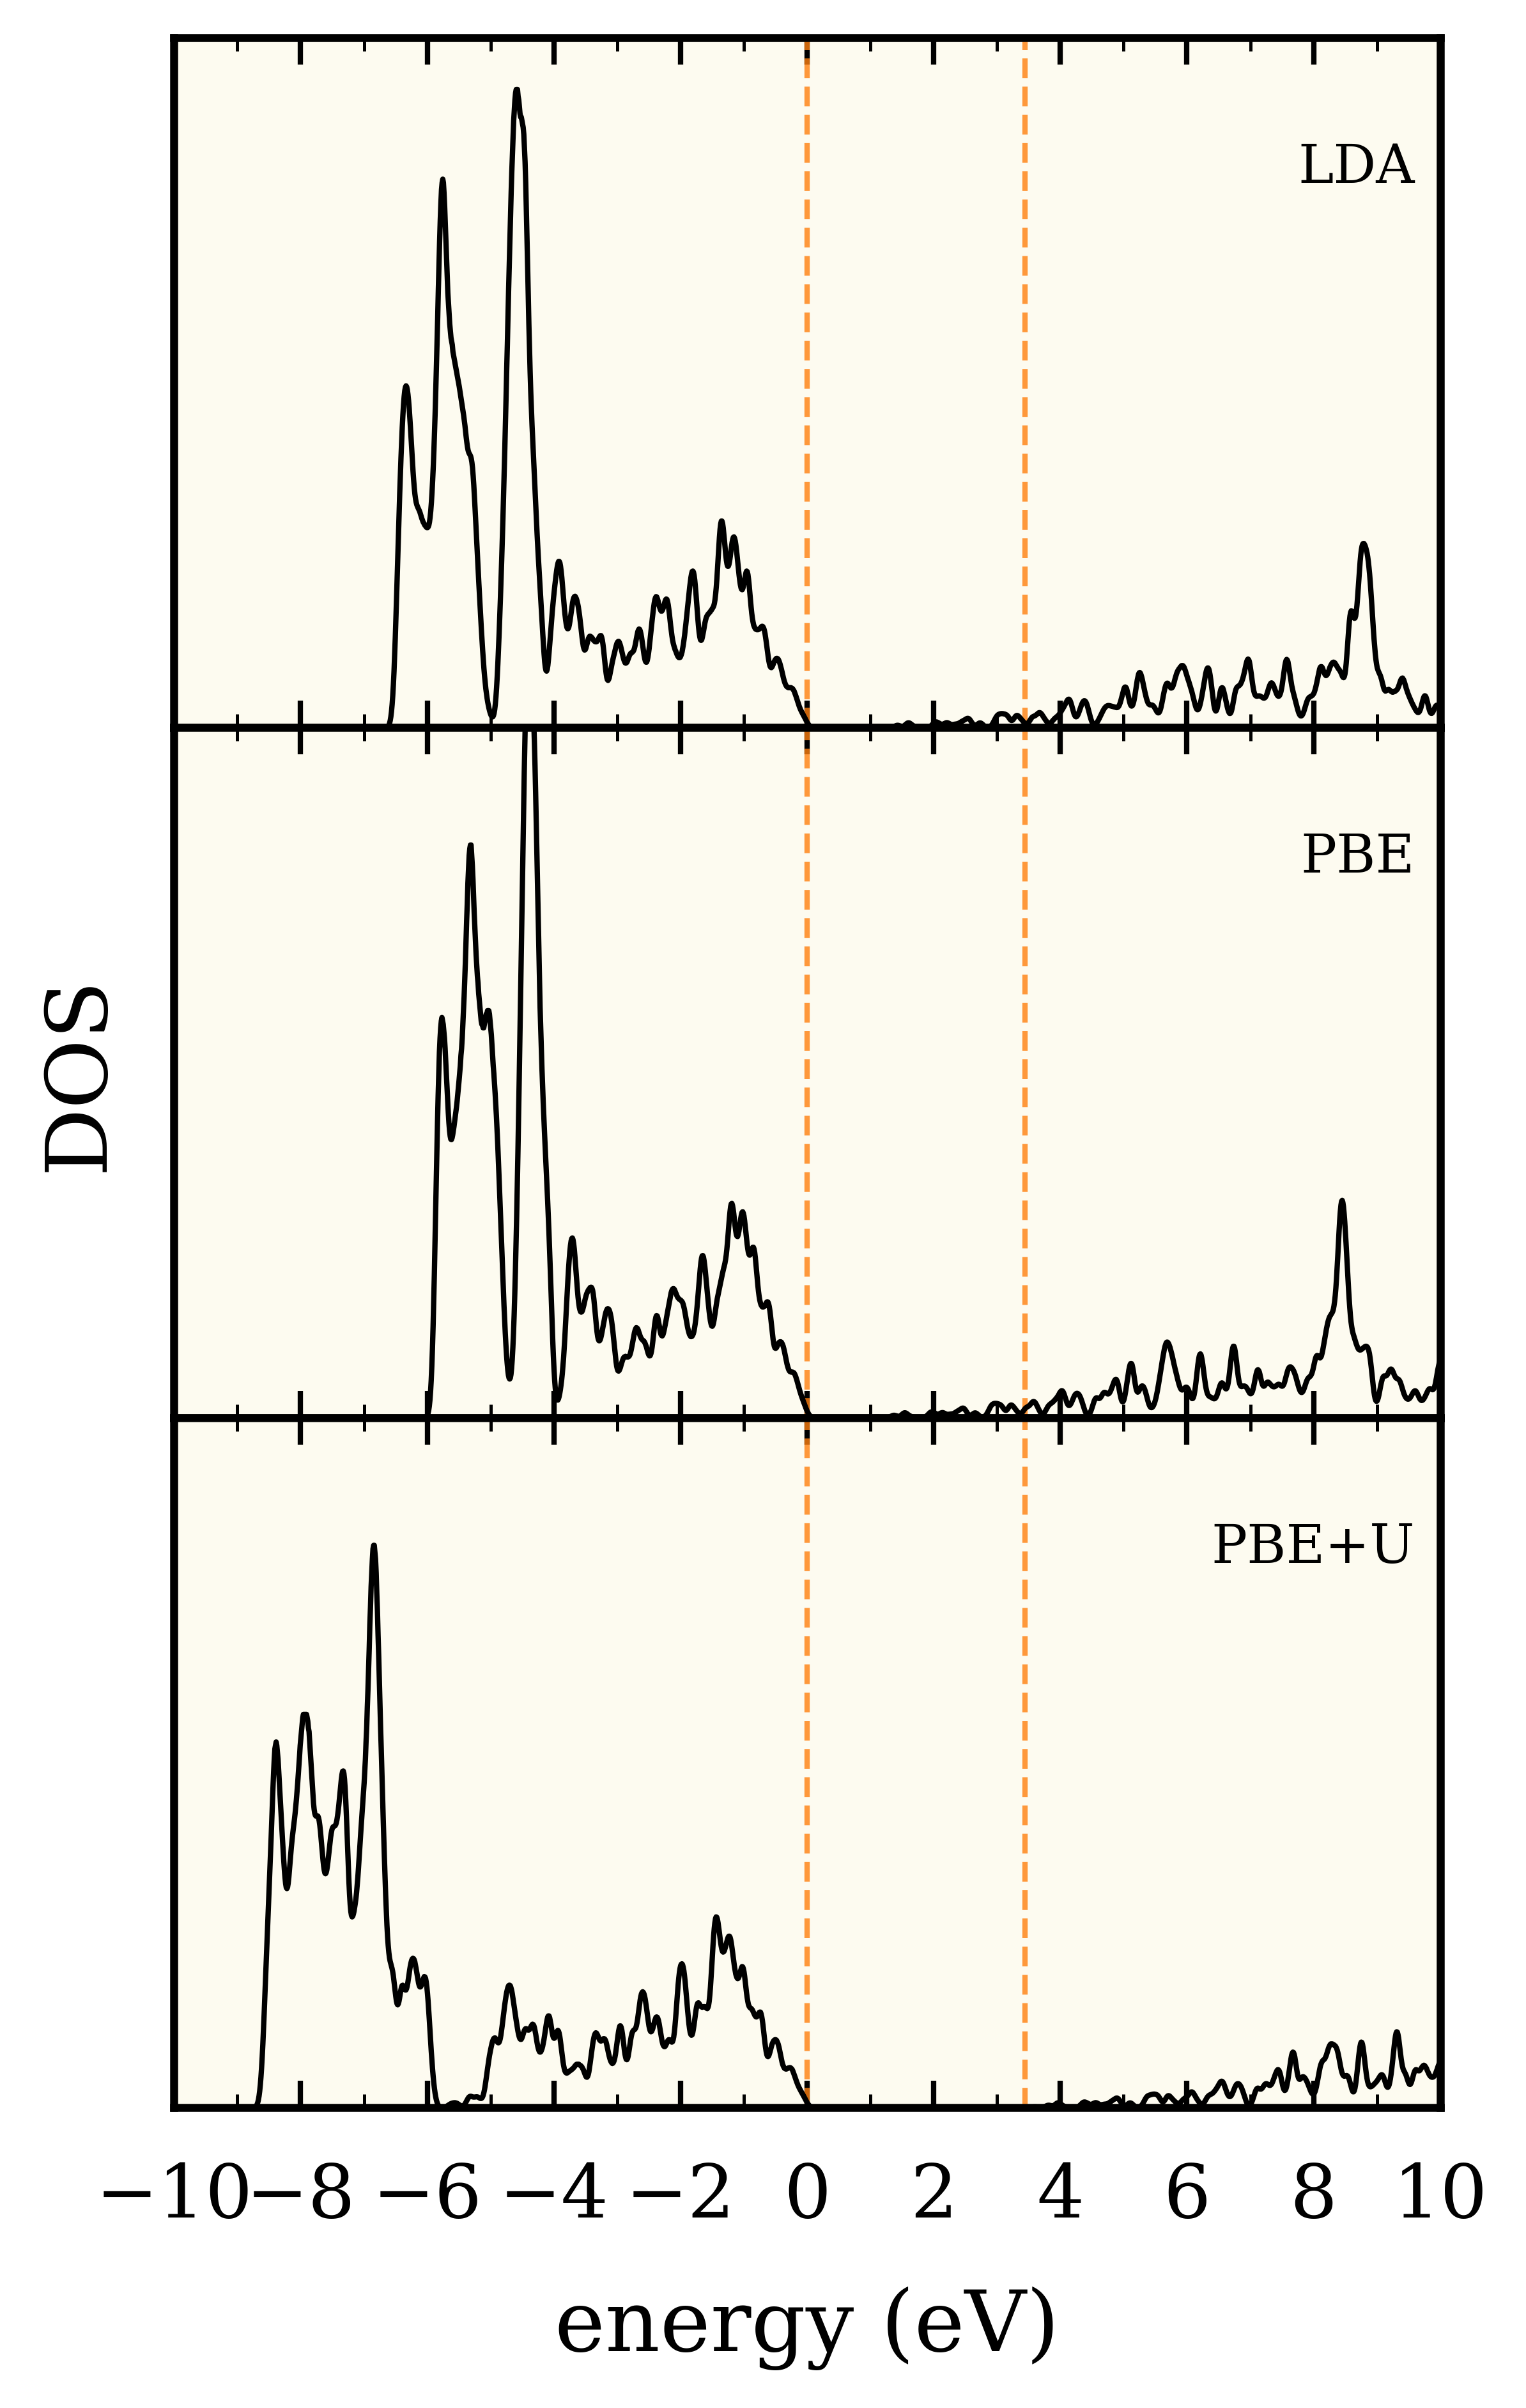

In [54]:
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

E_MIN, E_MAX = -10, 10
vlines = [0, 3.44]  
methods = ["LDA", "PBE", "PBE+U"]

fig, axes = plt.subplots(
    nrows=3,
    sharex=True,
    figsize=(4.2, 6.5),
    dpi=600,
    gridspec_kw=dict(hspace=0.00)
) 

for ax, method in zip(axes, methods):
    ax.set_xlim(E_MIN, E_MAX)
    ax.set_ylim(0, 20)
    ax.set_yticks([])
    ax.text(0.98, 0.85, method,transform=ax.transAxes,ha="right",va="top",fontdict=dict(size=10))
    ax.xaxis.set_major_locator(MultipleLocator(2))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    
    ax.xaxis.set_tick_params(which="major", direction="in", length=5)
    ax.xaxis.set_tick_params(which="minor", direction="in", length=2.5)

    for x in vlines:
        ax.axvline(x,color="tab:orange",lw=1,ls="--",alpha=0.8)    

axes[-1].set_xlabel("energy (eV)")
axes[1].set_ylabel("DOS")

# fig.text(-0.0, 0.5,"DOS (arbitrary units)",rotation="vertical",va="center")

axes[0].plot(e_lda - fermi["LDA"], dos_lda, color="black", label="Total", lw=1.0, zorder=3)
axes[1].plot(e_pbe - fermi["PBE"], dos_pbe, color="black", label="Total", lw=1.0, zorder=3)
axes[2].plot(e_pbeu - fermi["PBE+U"], dos_pbeu, color="black", label="Total", lw=1.0, zorder=3)

# fig.savefig("/home/jvc/ZnO_database/gallery/dos_panel.pdf", bbox_inches="tight")
plt.show()
